In [1]:
%cd /Data/gfi/users/rogui7909/code/predict_rain_norway

/felles_gfi/felles_gfi_users/rogui7909/code/predict_rain_norway


In [2]:
print('Running imports...')
import os
import os
os.environ["MKL_THREADING_LAYER"] = "GNU"

import wandb
import numpy as np
import torch # long
import xarray as xr

from coral_pytorch.losses import corn_loss
from coral_pytorch.dataset import corn_label_from_logits
from models.model import CNN_Model, CNN_Model_ChannelAttention, CNN_Model_SpatialAttention
import pandas as pd
from torch import nn
from lightning.pytorch import loggers, seed_everything
from models.lightning import LitCNN_regression, AttributableTrainer
# from models.losses import get_loss
import matplotlib
from models.data import get_input_data_from_wandb_logger,get_input_data_from_wandb_logger_three_types
# from models.model import get_model
import matplotlib.pyplot as plt
import cmocean.cm as cmo
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
plt.style.use('robin')
# matplotlib.use('tkagg')
torch.set_float32_matmul_precision('medium')
seed_everything(42, workers=True)
import seaborn as sns 
import argparse
from tqdm.notebook import tqdm
import cartopy.crs as ccrs

Running imports...


Seed set to 42


In [3]:
wandb_logger = loggers.WandbLogger(project="Predict-rain-WNorway_backtoclassif", 
                                    save_dir="/Data/gfi/users/rogui7909/wanbd_logs/",
                                    dir="/Data/gfi/users/rogui7909/wanbd_logs/wandb", )

wandb_logger.experiment # Initialize wandb

train_loader, val_loader, test_loader, ds_test = get_input_data_from_wandb_logger(wandb_logger, lon_lim=(-128, 53))

callbacks=[EarlyStopping(monitor="val/loss", mode="min")]
trainer = AttributableTrainer(limit_train_batches=100, 
                                max_epochs=wandb_logger.experiment.config['num_epochs'], 
                                logger=wandb_logger, 
                                log_every_n_steps=1, default_root_dir="/Data/gfi/users/rogui7909/lightning_checkpoint/",
                                callbacks=callbacks, deterministic=True,
                                accelerator="gpu", devices=1,)

wandb_logger.experiment.config['num_classes'] = wandb_logger.experiment.config['num_timesteps_predicted']*3
wandb_logger.experiment.config['num_channels'] = len(wandb_logger.experiment.config['input_variables'])

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: rguilcas (rguilcas-university-of-bergen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
/Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(
/Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(


/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Data ready:
    Image size: 2048 (64x32)
    Input data: u850, v850, z500, tcwv
    4 Predicted timesteps for future rainfall
    90th percentile predicted


In [4]:
class CNN_Model_2(nn.Module):
    def __init__(self, 
                 input_channels, 
                 image_size, 
                 num_timesteps,
                 number_conv_layers=3,
                 size_conv_kernel=3,
                 out_channels_conv1=12, 
                 out_channel_factor_increase_per_layer = 2,
                 ):
        super(CNN_Model_2, self).__init__()
        
        # CNN layers to extract spatial features
        # self.sigmoid = sigmoid
        # self.softmax = softmax
        self.num_timesteps = num_timesteps
        self.classes_per_timestep = 3
        self.num_classes = self.num_timesteps*(self.classes_per_timestep-1)
        self.number_conv_layers = number_conv_layers
        self.conv_layer1 = nn.Sequential(
                                     nn.Conv2d(input_channels, 
                                     out_channels_conv1, 
                                     kernel_size=size_conv_kernel, 
                                     stride=1, padding=(size_conv_kernel-1)//2),
                            nn.MaxPool2d(kernel_size=2, stride=2),
                            nn.ReLU())
        self.conv_layer2 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1, 
                                          out_channels_conv1*out_channel_factor_increase_per_layer, 
                                          kernel_size=size_conv_kernel, 
                                          stride=1, padding=(size_conv_kernel-1)//2),
                                nn.MaxPool2d(kernel_size=2, stride=2),
                                nn.ReLU())
        self.conv_layer3 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer, 
                                          out_channels_conv1*out_channel_factor_increase_per_layer**2, 
                                          kernel_size=size_conv_kernel, 
                                          stride=1, padding=(size_conv_kernel-1)//2),
                                nn.MaxPool2d(kernel_size=2, stride=2),
                                nn.ReLU())
        self.conv_layer4 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer**2, 
                                          out_channels_conv1*out_channel_factor_increase_per_layer**3, 
                                          kernel_size=size_conv_kernel, 
                                          stride=1, padding=(size_conv_kernel-1)//2),
                                nn.MaxPool2d(kernel_size=2, stride=2),
                                nn.ReLU())
        self.conv_layer5 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer**3, 
                                          out_channels_conv1*out_channel_factor_increase_per_layer**4, 
                                          kernel_size=size_conv_kernel, 
                                          stride=1, padding=(size_conv_kernel-1)//2),
                                nn.MaxPool2d(kernel_size=2, stride=2),
                                nn.ReLU())
        self.conv_layer6 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer**4, 
                                            out_channels_conv1*out_channel_factor_increase_per_layer**5, 
                                            kernel_size=size_conv_kernel, 
                                            stride=1, padding=1),
                                nn.MaxPool2d(kernel_size=(1,2), stride=2),
                                nn.ReLU())
        
        if number_conv_layers == 1:
            self.cnn = nn.Sequential(self.conv_layer1)
        elif number_conv_layers == 2:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2)
        elif number_conv_layers == 3:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3)
        elif number_conv_layers == 4:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3, self.conv_layer4)
        elif number_conv_layers == 5:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3, self.conv_layer4, self.conv_layer5)
        elif number_conv_layers == 6:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3, self.conv_layer4, self.conv_layer5, self.conv_layer6)
        
        max_pools = 4**(number_conv_layers)
        self.output_cnn_channels  = out_channels_conv1*out_channel_factor_increase_per_layer**(number_conv_layers-1)
        if self.number_conv_layers == 0:
            self.linear_size = image_size 
        else:
            self.linear_size = image_size * self.output_cnn_channels // max_pools 
        if self.number_conv_layers == 6:
            self.linear_size = self.linear_size*2
        if self.number_conv_layers == 0:
            self.linear_size = image_size*2 
        self.fc1 = nn.Linear(self.linear_size, 512)
        self.fc2 = nn.Linear(512, self.num_classes)
    
    def forward(self, x):
        # x shape: (batch_size, seq_length, channels, height, width)
        # Apply CNN to extract spatial features
        batch_size,  channels, height, width = x.size()
        if self.number_conv_layers>0:
            cnn_out = self.cnn(x)
        else:
            cnn_out = x
        cnn_out = cnn_out.view(batch_size, -1)  # Shape: (batch_size, seq_length, features)
        output = self.fc1(cnn_out)  # Shape: (batch_size, output_size)
        output = self.fc2(output)
        output = output.view(-1, self.num_timesteps, self.classes_per_timestep-1)
        output = torch.sigmoid(output) 
        X1 = output[:,:,0]
        X2 = output[:,:,1]
        P_norain = X1 
        P_rain = (1-X1)*(1-X2)
        P_extreme = (1-X1)*X2
        output = torch.stack([P_norain, P_rain, P_extreme], dim=2)
        return output.view(-1, self.num_timesteps*self.classes_per_timestep)
        # print(output.shape)
        
NN = CNN_Model_2(input_channels = wandb_logger.experiment.config['num_channels'], 
               image_size=wandb_logger.experiment.config['image_size'], 
               num_timesteps=wandb_logger.experiment.config['num_timesteps_predicted'],
               number_conv_layers=wandb_logger.experiment.config['num_conv_layer'],
               size_conv_kernel=wandb_logger.experiment.config['size_conv_kernel'],
               out_channels_conv1=wandb_logger.experiment.config['conv1_kernel_number'], 
               out_channel_factor_increase_per_layer = wandb_logger.experiment.config['factor_increase_kernels_per_conv_layer'],)
 
NN(train_loader.dataset[0][0][:20]).shape


torch.Size([20, 12])

In [5]:
import timm

class RainfallClassifier(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.backbone = timm.create_model(
            'convnext_base',
            pretrained=True,
            in_chans=in_channels,
            num_classes=0  # removes default classifier
        )
        self.head = nn.Sequential(
            # nn.AdaptiveAvgPool2d(1),
            # nn.Flatten(),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 8)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.head(x)
        output = x.view(-1, 4, 2)
        output = torch.sigmoid(output) 
        X1 = output[:,:,0]
        X2 = output[:,:,1]
        P_norain = X1 
        P_rain = (1-X1)*(1-X2)
        P_extreme = (1-X1)*X2
        output = torch.stack([P_norain, P_rain, P_extreme], dim=2)
        return output.view(-1, 12)

NN  = RainfallClassifier(1)

In [6]:
import timm
import torch
import torch.nn as nn

class ConvNeXtTinyRainClassifier(nn.Module):
    def __init__(self, in_channels=4, num_classes=4):  # Adjust channels/classes as needed
        super().__init__()
        # Load ConvNeXt-Tiny backbone
        self.backbone = timm.create_model(
            'convnext_tiny',
            pretrained=False,
            in_chans=in_channels,
            num_classes=0  # remove default classifier
        )

        # Add custom classification head
        self.head = nn.Sequential(
            # nn.AdaptiveAvgPool2d(1),  # from [B, C, H, W] → [B, C, 1, 1]
            # nn.Flatten(),             # → [B, C]
            nn.Linear(768, 256),      # ConvNeXt-Tiny has 768 output channels
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.head(x)
        return x
    
NN  = ConvNeXtTinyRainClassifier()

In [7]:
import torch
import torch.nn as nn

class PatchEmbedding(nn.Module):
    def __init__(self, in_channels, patch_size, emb_dim):
        super().__init__()
        self.patch_size = patch_size
        self.emb_dim = emb_dim
        self.proj = nn.Conv2d(in_channels, emb_dim, kernel_size=patch_size, stride=patch_size)

        self.pos_embed = None  # We'll create this dynamically

    def forward(self, x):
        # x: (B, C, H, W)
        x = self.proj(x)  # (B, emb_dim, H/P, W/P)
        B, D, Hp, Wp = x.shape
        x = x.flatten(2).transpose(1, 2)  # (B, N, D) where N = Hp * Wp

        # Create positional embeddings dynamically
        if self.pos_embed is None or self.pos_embed.shape[1] != x.shape[1]:
            self.pos_embed = nn.Parameter(torch.randn(1, x.shape[1], self.emb_dim, device=x.device))

        x = x + self.pos_embed
        return x  # (B, N, D)

class ViT_Model(nn.Module):
    def __init__(self, 
                 input_channels, 
                 num_timesteps,
                 patch_size=4,
                 emb_dim=128,
                 num_layers=6,
                 num_heads=8,
                 mlp_dim=256,
                 dropout=0.1):
        super().__init__()
        self.num_timesteps = num_timesteps
        self.classes_per_timestep = 3
        self.num_classes = self.num_timesteps * (self.classes_per_timestep - 1)

        self.patch_embed = PatchEmbedding(input_channels, patch_size, emb_dim)

        encoder_layer = nn.TransformerEncoderLayer(d_model=emb_dim, nhead=num_heads,
                                                   dim_feedforward=mlp_dim, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.norm = nn.LayerNorm(emb_dim)

        self.mlp_head = nn.Sequential(
            nn.Linear(emb_dim, 512),
            nn.ReLU(),
            nn.Linear(512, self.num_classes)
        )

    def forward(self, x):
        # x: (B, C, H, W)
        x = self.patch_embed(x)      # (B, N, D)
        x = self.transformer(x)      # (B, N, D)
        x = self.norm(x.mean(dim=1)) # (B, D), mean pooling
        x = self.mlp_head(x)         # (B, num_classes)
        
        x = x.view(-1, self.num_timesteps, self.classes_per_timestep - 1)
        x = torch.sigmoid(x)

        X1 = x[:, :, 0]
        X2 = x[:, :, 1]
        P_norain = X1
        P_rain = (1 - X1) * (1 - X2)
        P_extreme = (1 - X1) * X2
        out = torch.stack([P_norain, P_rain, P_extreme], dim=2)

        return out.view(-1, self.num_timesteps * self.classes_per_timestep)


NN = ViT_Model(input_channels = wandb_logger.experiment.config['num_channels'], 
               num_timesteps=wandb_logger.experiment.config['num_timesteps_predicted'],
               )
 
NN(train_loader.dataset[0][0][:20]).shape


torch.Size([20, 12])

In [8]:
# NN = CNN_Model_2(input_channels = wandb_logger.experiment.config['num_channels'], 
#                image_size=wandb_logger.experiment.config['image_size'], 
#                num_timesteps=wandb_logger.experiment.config['num_timesteps_predicted'],
#                number_conv_layers=wandb_logger.experiment.config['num_conv_layer'],
#                size_conv_kernel=wandb_logger.experiment.config['size_conv_kernel'],
#                out_channels_conv1=wandb_logger.experiment.config['conv1_kernel_number'], 
#                out_channel_factor_increase_per_layer = wandb_logger.experiment.config['factor_increase_kernels_per_conv_layer'],)
 
# NN = ViT_Model(input_channels = wandb_logger.experiment.config['num_channels'], 
#                num_timesteps=wandb_logger.experiment.config['num_timesteps_predicted'],
#                )
NN  = ConvNeXtTinyRainClassifier()

class MultiCrossEntropyLoss(nn.Module):
    def __init__(self, timesteps):
        super(MultiCrossEntropyLoss, self).__init__()
        self.nll = torch.nn.NLLLoss(weight = torch.Tensor([1,1,9]))
        self.timesteps = timesteps
        
    def forward(self, pred, target):
        """
        Computes the loss for the given prediction.
        """
        loss = []
        pred = pred.view(-1, self.timesteps, 3)
        proba = torch.softmax(pred, dim=2)
        for k,timestep in enumerate(range(self.timesteps)):
            res = self.nll(torch.log(proba[:,timestep]), target[:,timestep])
            loss.append(res)#*(k+1)/10)
        loss = torch.mean(torch.stack(loss))
        return loss
    

# loss = MultiCrossEntropyLoss(timesteps = wandb_logger.experiment.config['num_timesteps_predicted'])
loss = torch.nn.BCEWithLogitsLoss(pos_weight=torch.Tensor([9]))


model = LitCNN_regression(NN, 
                          learning_rate=wandb_logger.experiment.config['learning_rate'], 
                          lr_scheduler =wandb_logger.experiment.config['lr_scheduler'],
                          loss_fn = loss)


In [25]:
y_ = NN(train_loader.dataset[0][0][:20])
targets = train_loader.dataset[0][1][:20]
targets
y_

torch.nn.BCEWithLogitsLoss(pos_weight=torch.Tensor([9]))(y_, targets)

tensor(0.9857, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)

In [9]:
trainer.fit(model, train_loader, val_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type                       | Params | Mode 
---------------------------------------------------------------
0 | model   | ConvNeXtTinyRainClassifier | 28.0 M | train
1 | loss_fn | BCEWithLogitsLoss          | 0      | train
---------------------------------------------------------------
28.0 M    Trainable params
0         Non-trainable params
28.0 M    Total params
112.078   Total estimated model params size (MB)
256       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [10]:
model.eval()
with torch.no_grad():
    trainer.test(model, dataloaders=val_loader)
wandb.finish()

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │     0.850640058517456     │
└───────────────────────────┴───────────────────────────┘

epoch,▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇█████
test/loss,▁
train/loss,▅█▅▃▇▅▅▅▂▅▅▃▃▅▅▄▃▂▄▄▅▄▃▅▁▄▁▃▃▃▄▃▁▃▁▃▃▂▂▃
trainer/global_step,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇████
val/loss,█▆▄▄▄▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
epoch,54
test/loss,0.85064
train/loss,0.71228
trainer/global_step,1620
val/loss,0.85064


In [13]:
y_test = torch.stack(model.test_true_values)#.cpu().numpy()
y_scores = torch.sigmoid(torch.stack(model.test_pred))#.view(-1, wandb_logger.experiment.config['num_timesteps_predicted'], 3)#.cpu().numpy()

In [14]:
targets=xr.DataArray(y_test.cpu().numpy(), dims=['time','timestep'], coords=dict(time=ds_test.time, timestep=np.arange(y_scores.shape[1])))
proba=xr.DataArray(y_scores.cpu().numpy(), dims=['time','timestep'], coords=dict(time=ds_test.time, timestep=np.arange(y_scores.shape[1])))
preds_thresh = xr.DataArray(np.arange(0,1.1,.1), dims=['pred_thresh'], coords=dict(pred_thresh=np.arange(0,1.1,.1)))
preds = (proba>preds_thresh)*1

TP = ((preds == targets)&(targets==1)).sum('time')
recall = TP / (targets==1).sum('time')
precision = TP / (preds==1).sum('time')
f1 = 2*(precision*recall)/(precision+recall)

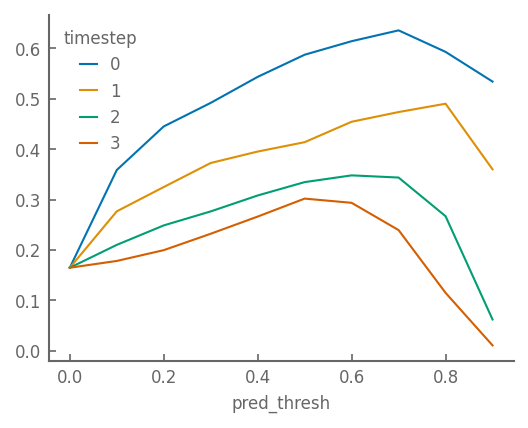

In [15]:
f1.plot(hue='timestep')

In [18]:
y_test = torch.stack(model.test_true_values)#.cpu().numpy()
y_scores = torch.stack(model.test_pred).view(-1, wandb_logger.experiment.config['num_timesteps_predicted'], 3)#.cpu().numpy()
preds = torch.argmax(y_scores, dim=2)
targets=xr.DataArray(y_test.cpu().numpy(), dims=['time','timestep'], coords=dict(time=ds_test.time, timestep=np.arange(y_scores.shape[1])))
preds=xr.DataArray(preds.cpu().numpy(), dims=['time','timestep'], coords=dict(time=ds_test.time, timestep=np.arange(y_scores.shape[1])))
results = xr.Dataset(dict(targets=targets, preds=preds))
proba=xr.DataArray(y_scores.cpu().numpy(), dims=['time','timestep','type_rain'], 
                   coords=dict(time=ds_test.time, timestep=np.arange(y_scores.shape[1]), type_rain=['no_rain','moderate_rain','extreme_rain']))
df_=pd.DataFrame(dict(pred=preds.to_series(), targets=targets.to_series()))
df_['pred_time'] = (df_.index.get_level_values(0)+pd.Timedelta(1,'D')*df_.index.get_level_values(1)).values
# model.test_true_values

# pred = torch.stack([corn_label_from_logits(y_scores[:,k]) for k in range(y_scores.shape[1])])

[Text(0, 0, 'D0'), Text(1, 0, 'D+1'), Text(2, 0, 'D+2'), Text(3, 0, 'D+3')]

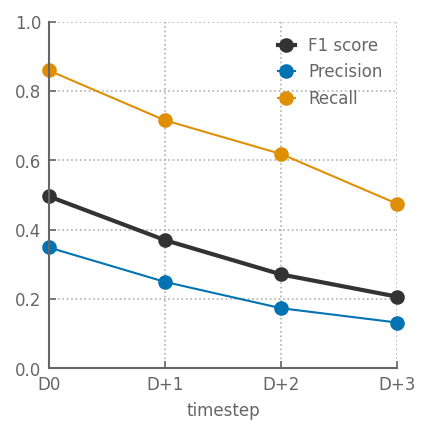

In [19]:
TP = ((preds == targets)&(targets==2)).sum('time')
recall = TP / (targets==2).sum('time')
precision = TP / (preds==2).sum('time')
f1 = 2*(precision*recall)/(precision+recall)



# recall_season.plot(hue='season')
fig, ax = plt.subplots(figsize=(3,3,))
f1.plot(color='.2', lw=2, label='F1 score', marker='o', clip_on=False)
precision.plot(label='Precision', marker='o', clip_on=False)
recall.plot(label='Recall', marker='o', clip_on=False)
plt.legend()
ax.set_ylim(0,1)
ax.grid()
ax.set_xlim(0,3)
ax.set_xticks([0,1,2,3])
ax.set_xticklabels(['D0','D+1','D+2','D+3'])

In [ ]:
df_=pd.DataFrame(dict(pred=preds.to_series(), targets=targets.to_series()))
df_['pred_time'] = (df_.index.get_level_values(0)+pd.Timedelta(1,'D')*df_.index.get_level_values(1)).values

times = df_.query("targets==2 & pred==2").groupby('pred_time').count().pred.sort_values()
events_predicted = times.loc[times>3].index
steps = 4
start_times = events_predicted -  pd.Timedelta(steps-1,'D')
print("Number of 4x events:",len(start_times))
num_extremes = df_.targets.loc[df_.targets==2].unstack().count(axis=1)
num_extremes_pred = df_.targets.where((df_.targets==2)&(df_.pred==2)).fillna(0).unstack().sum(axis=1)//2

pred_FP = df_.query("pred==2 & targets<2").groupby('pred_time').count().query("pred==4").index

start_times_FP = pred_FP - pd.Timedelta(steps-1,'D')
# events

Number of 4x events: 72


In [15]:
%%time
steps = 4

from captum.attr import IntegratedGradients
method = IntegratedGradients(model.model)
all_multi_attrs = []
all_multi_sens = []

for k in tqdm(range(len(events_predicted))):
    start = start_times[k].strftime("%Y-%m-%d %H:%M:%S")
    end = events_predicted[k].strftime("%Y-%m-%d %H:%M:%S")
    # print(start,end)
    ds_test_extract = ds_test.sel(time=slice(start ,end))
    tensor_in = torch.Tensor(ds_test_extract.inputs.values)
    tensor_out = torch.Tensor(ds_test_extract.targets.values)
    attrs = method.attribute(tensor_in, baselines=torch.Tensor([0]),target=[3*(steps-k)-1 for k in range(steps)]) 
    da_attrs = xr.DataArray(attrs, dims = ['timestep','var_name','latitude','longitude'], 
                            coords= dict(timestep=np.arange(1,steps+1),var_name=ds_test_extract.var_name, latitude=ds_test_extract.latitude, longitude=ds_test_extract.longitude))
    all_multi_attrs.append(da_attrs.assign_coords(time=events_predicted[k]))
    sens = da_attrs/ds_test_extract.inputs.rename(time='timestep').assign_coords(timestep=da_attrs.timestep)
    all_multi_sens.append(sens.assign_coords(time=events_predicted[k]))
ds_attributions = xr.concat(all_multi_attrs, dim='time')
ds_sens = xr.concat(all_multi_sens, dim='time')

  0%|          | 0/72 [00:00<?, ?it/s]

CPU times: user 1min 48s, sys: 4.2 s, total: 1min 52s
Wall time: 9.96 s


In [13]:
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Polygon

import cartopy.crs as ccrs
import matplotlib.ticker as mticker
def clean_map(plot, boundaries=(-90, 50, 0, 90)):
    projection = ccrs.LambertConformal(central_longitude=-15.0, central_latitude=39.0)
    lon_min, lon_max , lat_min, lat_max = boundaries
    for ax in plot.axs.flatten():
        ax.coastlines()
        # ax.set_extent((-60,60,0,80))
        ax.set_extent(boundaries, crs=ccrs.PlateCarree())
        
        # ax.set_extent((-60,60,20,80), crs=ccrs.PlateCarree())

        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                    linewidth=.5, color='gray', alpha=0.5, linestyle='-')
        gl.xlocator = mticker.FixedLocator(np.linspace(ds_test.longitude.min(),ds_test.longitude.max(),17)[:-1])
        gl.ylocator = mticker.FixedLocator(np.arange(0,81,20))
        
        longitudes = np.linspace(lon_min, lon_max, 100)
        latitudes = np.linspace(lat_min, lat_max,100)
        xx = list(longitudes)[::-1]+\
                [longitudes.min() for _ in range(latitudes.size)] + \
                    list(longitudes)+\
                        [longitudes.max() for _ in range(latitudes.size)]
        yy = [latitudes.max() for _ in range(longitudes.size)] \
                + list(latitudes)[::-1]+\
                    [latitudes.min() for _ in range(longitudes.size)]+ \
                        list(latitudes)[::-1]
        verts = np.array([xx, yy]).T
        circle = Path(verts)
        ax.set_boundary(circle, transform=ccrs.PlateCarree())
        # break
    # ax.set_extent((-60,60,20,80), crs=ccrs.PlateCarree())

def clean_map_nocut(plot):
    projection = ccrs.LambertConformal(central_longitude=-15.0, central_latitude=39.0)
    for ax in plot.axs.flatten():
        ax.coastlines()
        # ax.set_extent((-60,60,0,80))
        # ax.set_extent([-90, 60, 20, 80], crs=ccrs.PlateCarree())
        
        # ax.set_extent((-60,60,20,80), crs=ccrs.PlateCarree())

        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                    linewidth=.5, color='gray', alpha=0.5, linestyle='--')
        gl.xlocator = mticker.FixedLocator(np.linspace(ds_test.longitude.min(),ds_test.longitude.max(),17)[:-1])
        gl.ylocator = mticker.FixedLocator(np.arange(20,81,20))
        
        # longitudes = np.linspace(-90, 60, 100)
        # latitudes = np.linspace(20,80,100)
        # xx = list(longitudes)[::-1]+\
        #         [longitudes.min() for _ in range(latitudes.size)] + \
        #             list(longitudes)+\
        #                 [longitudes.max() for _ in range(latitudes.size)]
        # yy = [latitudes.max() for _ in range(longitudes.size)] \
        #         + list(latitudes)[::-1]+\
        #             [latitudes.min() for _ in range(longitudes.size)]+ \
        #                 list(latitudes)[::-1]
        # verts = np.array([xx, yy]).T
        # circle = Path(verts)
        # ax.set_boundary(circle, transform=ccrs.PlateCarree())
        # break
    # ax.set_extent((-60,60,20,80), crs=ccrs.PlateCarree())
    

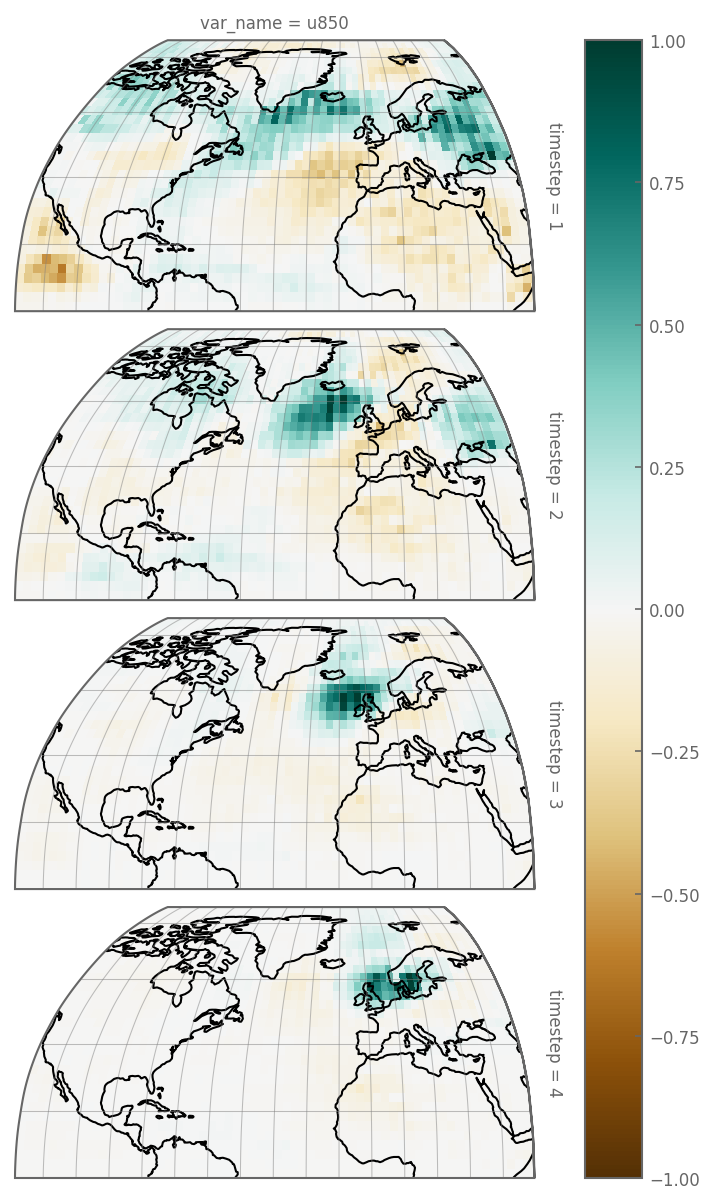

In [14]:

test = ds_attributions.mean('time')#.isel(time=5)#.coarsen(longitude=3,latitude=3,boundary='trim').sum()
test_max = test/test.max(['longitude','latitude', 'var_name'])
projection = ccrs.LambertConformal(central_longitude=-15.0, central_latitude=39.0)
projection = ccrs.Robinson(central_longitude=-15.0)

# test = test.where(test>0.01*test.max(['longitude','latitude','var_name']))
test = test.where(np.abs(test)>1e-3,0)
plot = test_max.plot(row='timestep', col='var_name', subplot_kws = dict(projection=projection), aspect=3, size=2, transform=ccrs.PlateCarree(),
                #  norm = matplotlib.colors.SymLogNorm(linthresh=0.002,linscale=.2), 
                 cmap='BrBG')

clean_map(plot, boundaries = (-125, 50, 0, 90))

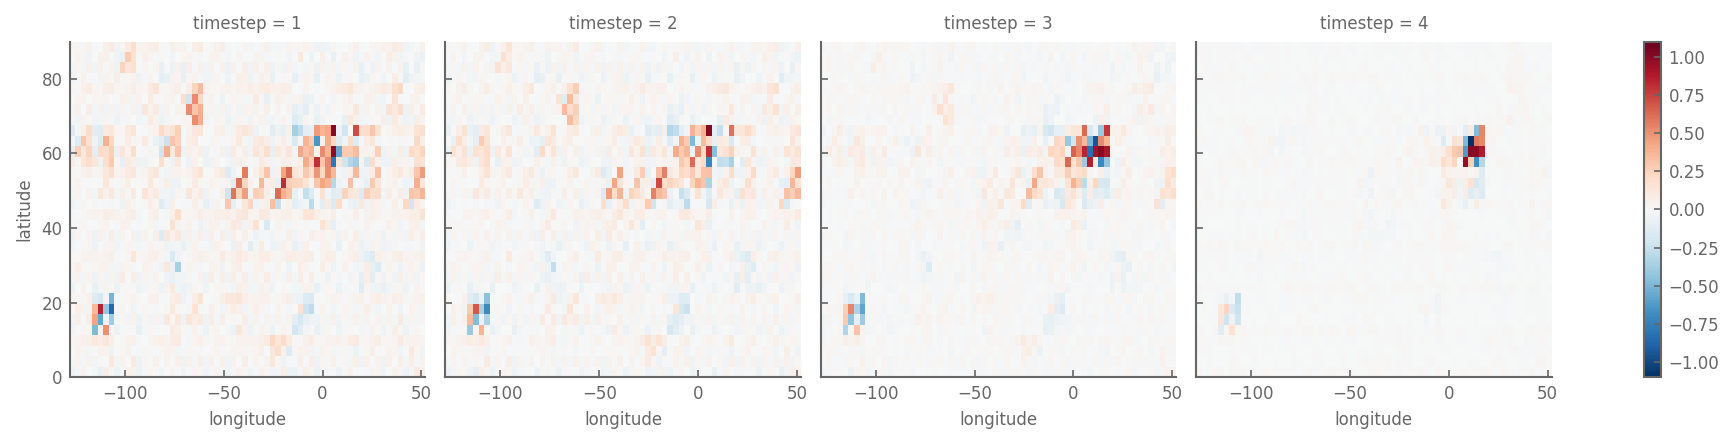

In [17]:
(ds_sens.mean('time')/ds_sens.mean('time').max(['longitude','latitude'])).plot(col='timestep')

In [ ]:
final_ds = xr.Dataset(dict(attributions = ds_attributions, sensitivity=ds_sens))
final_ds = final_ds.rename(time='attribution_time')
final_ds = xr.merge([final_ds, results.assign_coords(timestep=np.arange(1,5))])
n = wandb_logger.experiment.config['num_conv_layer']
final_ds.to_netcdf(f'out_data/rosendal/u850_{n}conv_layer_attributions.nc')

In [20]:
# final_ds.to_netcdf('out_data/rosendal/4conv_layer_linus_style_attributions.nc')
final_ds.to_netcdf('out_data/rosendal/ViT_patch4_attributions.nc')